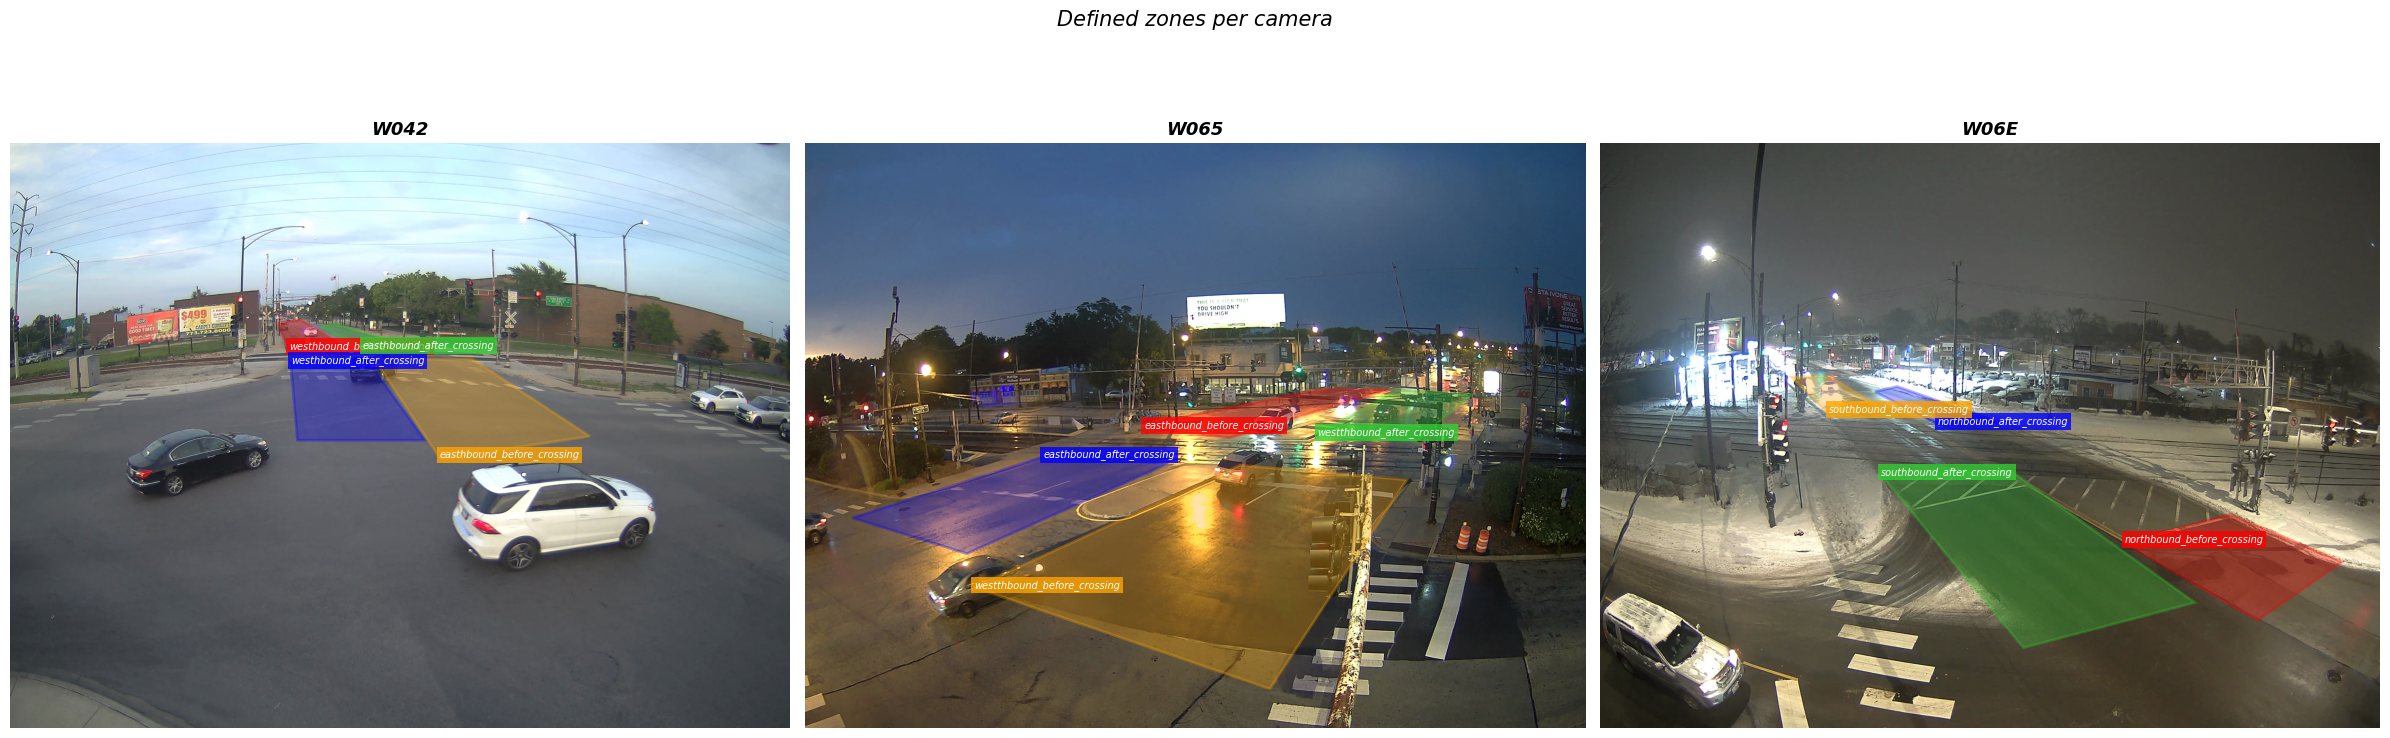

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Polygon
import json
from pathlib import Path
from utils import get_image_file_names

# ── define all 3 camera paths ─────────────────────────────────────────────────
CAMERAS = {
    "W042": Path("C:/Users/Zahra/Box/UofT-UIC-/second run in UIC/IDOT-20260423T161905Z-3-001/IDOT/W042_08-09-2025/W042_08-09-2025"),
    "W065": Path("C:/Users/Zahra/Box/UofT-UIC-/second run in UIC/IDOT-20260423T161905Z-3-001/IDOT/W065_08-17-2025/W065_08-17-2025"),
    "W06E": Path("C:/Users/Zahra/Box/UofT-UIC-/second run in UIC/IDOT-20260423T161905Z-3-001/IDOT/W06E_12-02-2025/W06E_12-02-2025"),  # adjust name
}

COLORS = ["red", "blue", "limegreen", "orange", "purple", "cyan", "magenta", "yellow"]

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, (cam_name, data_path) in zip(axes, CAMERAS.items()):
    save_path  = data_path / "bounding_boxes.json"
    image_path = data_path / "images"

    # load image
    file_paths, _, _ = get_image_file_names(image_path)
    img = mpimg.imread(str(file_paths[10]))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(cam_name, fontsize=13, fontweight="bold")

    # load and draw zones
    if not save_path.exists():
        ax.set_title(f"{cam_name}\n(no bounding_boxes.json found)", fontsize=11)
        continue

    all_zones = json.loads(save_path.read_text())

    for i, (zone_name, pts) in enumerate(all_zones.items()):
        color = COLORS[i % len(COLORS)]
        polygon = Polygon(pts, edgecolor=color, facecolor=color, alpha=0.3, linewidth=2)
        ax.add_patch(polygon)
        ax.text(pts[0][0], pts[0][1], zone_name,
                fontsize=7, color="white",
                bbox=dict(facecolor=color, alpha=0.8, pad=2, edgecolor="none"))

plt.suptitle("Defined zones per camera", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
#Modify the coordinates of some corners.

In [4]:
%matplotlib tk
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Polygon
import numpy as np
import json
from pathlib import Path
from utils import get_image_file_names

# ── pick which camera to edit ─────────────────────────────────────────────────
DATA_PATH  = Path("C:/Users/Zahra/Box/UofT-UIC-/second run in UIC/IDOT-20260423T161905Z-3-001/IDOT/W042_08-09-2025/W042_08-09-2025")
IMAGE_PATH = DATA_PATH / "images"
SAVE_PATH  = DATA_PATH / "bounding_boxes.json"

file_paths, _, _ = get_image_file_names(IMAGE_PATH)
all_zones = json.loads(SAVE_PATH.read_text())
print("Loaded zones:", list(all_zones.keys()))

COLORS = ["red", "blue", "limegreen", "orange", "purple", "cyan", "magenta", "yellow"]

# ── build figure ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(mpimg.imread(str(file_paths[10])))
ax.axis("off")
ax.set_title("Drag any corner to move it  |  S = save  |  Z = undo last drag")

# draw all zones and collect draggable corner dots
zone_names  = list(all_zones.keys())
zone_pts    = [np.array(all_zones[name], dtype=float) for name in zone_names]
patches_map = {}   # zone_idx → Polygon patch
dot_map     = {}   # (zone_idx, pt_idx) → dot artist

for i, (name, pts) in enumerate(zip(zone_names, zone_pts)):
    color = COLORS[i % len(COLORS)]
    poly  = Polygon(pts, edgecolor=color, facecolor=color, alpha=0.25, linewidth=2)
    ax.add_patch(poly)
    patches_map[i] = (poly, color)
    ax.text(pts[0][0], pts[0][1], name, fontsize=7, color="white",
            bbox=dict(facecolor=color, alpha=0.8, pad=2, edgecolor="none"))
    for j, (x, y) in enumerate(pts):
        dot, = ax.plot(x, y, 'o', color=color, markersize=9, markeredgecolor='white', lw=1.5, picker=6)
        dot_map[(i, j)] = dot

# ── drag state ────────────────────────────────────────────────────────────────
drag_state  = {"active": None}   # (zone_idx, pt_idx) or None
undo_stack  = []                 # list of (zone_idx, pt_idx, old_x, old_y)

def _redraw_polygon(zone_idx):
    poly, color = patches_map[zone_idx]
    poly.set_xy(zone_pts[zone_idx])

def on_pick(event):
    # find which (zone_idx, pt_idx) was clicked
    for key, dot in dot_map.items():
        if dot is event.artist:
            drag_state["active"] = key
            return

def on_motion(event):
    if drag_state["active"] is None or event.inaxes != ax:
        return
    zi, pi = drag_state["active"]
    zone_pts[zi][pi] = [event.xdata, event.ydata]
    dot_map[(zi, pi)].set_data([event.xdata], [event.ydata])
    _redraw_polygon(zi)
    fig.canvas.draw_idle()

def on_release(event):
    if drag_state["active"] is not None:
        zi, pi = drag_state["active"]
        undo_stack.append((zi, pi, *zone_pts[zi][pi]))
    drag_state["active"] = None

def on_key(event):
    if event.key == 's':
        updated = {name: zone_pts[i].astype(int).tolist()
                   for i, name in enumerate(zone_names)}
        SAVE_PATH.write_text(json.dumps(updated, indent=2))
        print(f"✅ Saved to {SAVE_PATH}")
        print({k: v for k, v in updated.items()})
    elif event.key == 'z' and undo_stack:
        zi, pi, x, y = undo_stack.pop()
        zone_pts[zi][pi] = [x, y]
        dot_map[(zi, pi)].set_data([x], [y])
        _redraw_polygon(zi)
        fig.canvas.draw_idle()
        print(f"↩ Undid last move on zone {zone_names[zi]}, corner {pi}")

fig.canvas.mpl_connect('pick_event',         on_pick)
fig.canvas.mpl_connect('motion_notify_event', on_motion)
fig.canvas.mpl_connect('button_release_event', on_release)
fig.canvas.mpl_connect('key_press_event',    on_key)

plt.tight_layout()
plt.show()

Loaded zones: ['westhbound_before_crossing', 'westhbound_after_crossing', 'easthbound_after_crossing', 'easthbound_before_crossing']
